# Robustez: quando a média mente

**Tema:** Estatística › Fundamentos e Estatística Descritiva

No notebook anterior vimos *que* a média quebra. Agora vamos ao trabalho de
verdade: **detectar** contaminação de forma sistemática e — o ponto mais
importante e mais ignorado — decidir se o valor extremo é **erro** (deve sair)
ou **fenômeno** (deve ficar, e provavelmente é o mais valioso do dataset).

> **Analogia central:** um detector de outliers é um alarme de incêndio. Ele
> não sabe distinguir um incêndio de uma torrada queimada. Quem decide é você,
> olhando o contexto. Um sistema que remove automaticamente tudo o que o alarme
> aponta é um sistema que joga fora o café da manhã todo dia de manhã — e que,
> em detecção de fraude, joga fora exatamente as fraudes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(7)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("pronto")

pronto


## 1. Três regras clássicas de detecção — e por que duas delas falham

### Regra 1: z-score (a que quase todo mundo usa e quase ninguém deveria)

$$z_i = \frac{x_i - \bar{x}}{s}, \qquad \text{marca outlier se } |z_i| > 3$$

O problema é circular e fatal: a regra usa **média** e **desvio-padrão** para
encontrar outliers, mas média e desvio-padrão são **destruídos** por outliers.
É como pedir para o suspeito conduzir a própria investigação.

Esse efeito tem nome: **mascaramento** (*masking*). Um outlier grande infla
tanto o $s$ que ele próprio passa a ter $|z| < 3$ — e escapa.

In [2]:
# Dados limpos: 200 medições de temperatura de um sensor industrial (°C)
limpo = rng.normal(loc=75, scale=2.0, size=200)


def detecta_zscore(v, limite=3.0):
    z = (v - v.mean()) / v.std(ddof=1)
    return np.abs(z) > limite, z


def detecta_zscore_robusto(v, limite=3.5):
    """Z-score modificado de Iglewicz-Hoaglin: usa mediana e MAD.

    O 0.6745 é o quantil 0.75 da normal padrão — a constante que coloca o MAD
    na mesma escala de um desvio-padrão para dados normais.
    """
    mediana = np.median(v)
    mad = np.median(np.abs(v - mediana))
    z_mod = 0.6745 * (v - mediana) / mad
    return np.abs(z_mod) > limite, z_mod


def detecta_iqr(v, k=1.5):
    """Regra de Tukey, a do boxplot: fora de [Q1 - k·IQR, Q3 + k·IQR]."""
    q1, q3 = np.percentile(v, [25, 75])
    iqr = q3 - q1
    return (v < q1 - k * iqr) | (v > q3 + k * iqr), None


def compara_detectores(n_ruins, semente=7):
    """Contamina a série com `n_ruins` leituras absurdas e testa os 3 métodos."""
    r = np.random.default_rng(semente)
    ruins = r.uniform(180, 210, size=n_ruins)
    v = np.concatenate([limpo, ruins])
    m_z, z = detecta_zscore(v)
    m_zr, z_r = detecta_zscore_robusto(v)
    m_iqr, _ = detecta_iqr(v)
    return {
        "n_ruins": n_ruins,
        "z clássico": m_z[-n_ruins:].sum(),
        "z robusto (MAD)": m_zr[-n_ruins:].sum(),
        "IQR/Tukey": m_iqr[-n_ruins:].sum(),
        "|z| máximo": np.abs(z).max(),
        "|z_rob| mínimo dos intrusos": np.abs(z_r[-n_ruins:]).min(),
    }


# Cenário A: poucas leituras ruins (um glitch isolado)
print("CENÁRIO A — 3 leituras defeituosas em 200")
for k, v in compara_detectores(3).items():
    print(f"   {k:32s} {v:>10.2f}" if isinstance(v, float) else f"   {k:32s} {v:>10}")

# Cenário B: o sensor degradou e ficou 30 leituras fora de calibração
print("\nCENÁRIO B — 30 leituras defeituosas em 200")
for k, v in compara_detectores(30).items():
    print(f"   {k:32s} {v:>10.2f}" if isinstance(v, float) else f"   {k:32s} {v:>10}")

CENÁRIO A — 3 leituras defeituosas em 200
   n_ruins                                   3
   z clássico                                3
   z robusto (MAD)                           3
   IQR/Tukey                                 3
   |z| máximo                             8.34
   |z_rob| mínimo dos intrusos           72.62

CENÁRIO B — 30 leituras defeituosas em 200
   n_ruins                                  30
   z clássico                                0
   z robusto (MAD)                          30
   IQR/Tukey                                30
   |z| máximo                             2.91
   |z_rob| mínimo dos intrusos           51.06


Compare os dois cenários. No cenário A o z-score clássico funciona: os 3
intrusos têm $|z| \approx 8$ e são pegos. No cenário B, com **30** leituras
defeituosas de valor idêntico ao cenário A, o z-score clássico detecta
**zero** — o maior $|z|$ da amostra inteira nem chega a 3.

Nada mudou nos intrusos. O que mudou foi o **denominador**: eles inflaram
tanto o $s$ que passaram a caber dentro do próprio critério. Esse é o
**mascaramento** (*masking*), e é a razão de fundo pela qual o z-score clássico
não serve para detecção.

O z-score robusto atribui $|z| > 50$ aos intrusos nos dois cenários, porque a
mediana e o MAD simplesmente não tomam conhecimento deles.

Vamos ver a transição acontecer.

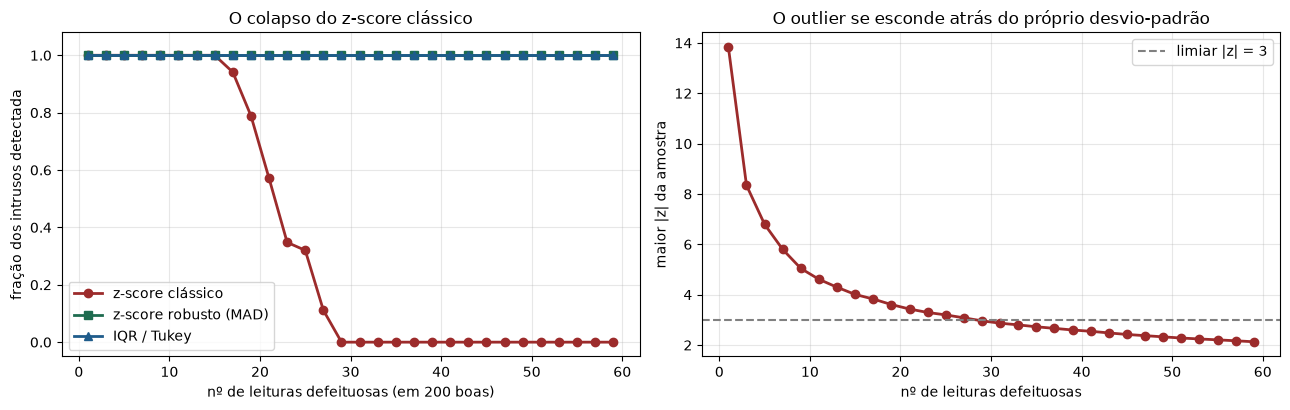

In [3]:
sweep = pd.DataFrame([compara_detectores(k) for k in range(1, 61, 2)])
sweep["taxa z clássico"] = sweep["z clássico"] / sweep["n_ruins"]
sweep["taxa z robusto"] = sweep["z robusto (MAD)"] / sweep["n_ruins"]
sweep["taxa IQR"] = sweep["IQR/Tukey"] / sweep["n_ruins"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))

ax1.plot(sweep["n_ruins"], sweep["taxa z clássico"], "o-", lw=2,
         color="#9C2B2B", label="z-score clássico")
ax1.plot(sweep["n_ruins"], sweep["taxa z robusto"], "s-", lw=2,
         color="#1E6B4F", label="z-score robusto (MAD)")
ax1.plot(sweep["n_ruins"], sweep["taxa IQR"], "^-", lw=2,
         color="#1F5C8B", label="IQR / Tukey")
ax1.set_xlabel("nº de leituras defeituosas (em 200 boas)")
ax1.set_ylabel("fração dos intrusos detectada")
ax1.set_title("O colapso do z-score clássico")
ax1.set_ylim(-0.05, 1.08)
ax1.legend()

ax2.plot(sweep["n_ruins"], sweep["|z| máximo"], "o-", lw=2, color="#9C2B2B")
ax2.axhline(3.0, ls="--", color="gray", label="limiar |z| = 3")
ax2.set_xlabel("nº de leituras defeituosas")
ax2.set_ylabel("maior |z| da amostra")
ax2.set_title("O outlier se esconde atrás do próprio desvio-padrão")
ax2.legend()

plt.tight_layout()
plt.show()

O painel da direita é a explicação mecânica em uma linha: conforme a
contaminação cresce, o maior $|z|$ **desce** e cruza o limiar de 3. Quanto pior
o problema, menos o detector o enxerga.

> **Regra prática que vale carregar para a carreira:** nunca use z-score
> clássico para *detectar* outliers. Use MAD ou IQR. O z-score clássico serve
> para **padronizar** dados já limpos, não para limpá-los.

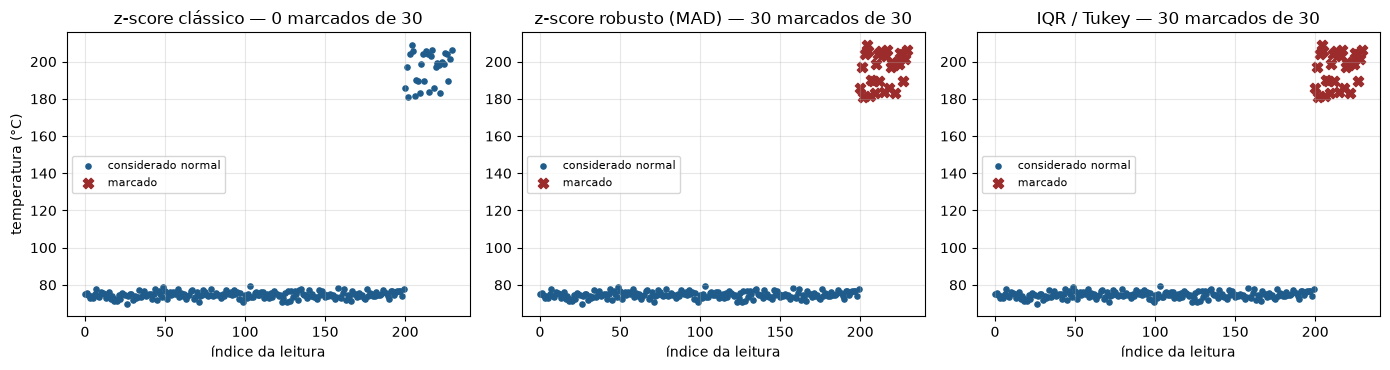

In [4]:
contaminado = np.concatenate([limpo, rng.uniform(180, 210, size=30)])
mascara_z, _ = detecta_zscore(contaminado)
mascara_zr, _ = detecta_zscore_robusto(contaminado)
mascara_iqr, _ = detecta_iqr(contaminado)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, (titulo, m) in zip(axes, [("z-score clássico", mascara_z),
                                  ("z-score robusto (MAD)", mascara_zr),
                                  ("IQR / Tukey", mascara_iqr)]):
    ax.scatter(np.arange(len(contaminado))[~m], contaminado[~m],
               s=14, color="#1F5C8B", label="considerado normal")
    ax.scatter(np.arange(len(contaminado))[m], contaminado[m],
               s=55, color="#9C2B2B", marker="X", label="marcado")
    ax.set_title(f"{titulo} — {m.sum()} marcados de 30")
    ax.set_xlabel("índice da leitura")
    ax.legend(loc="center left", fontsize=8)
axes[0].set_ylabel("temperatura (°C)")
plt.tight_layout()
plt.show()

## 2. Quanto de contaminação cada estimador aguenta?

Vamos medir o **ponto de ruptura** empiricamente: contaminamos uma fração
crescente da amostra e vemos quando cada estimador desiste.

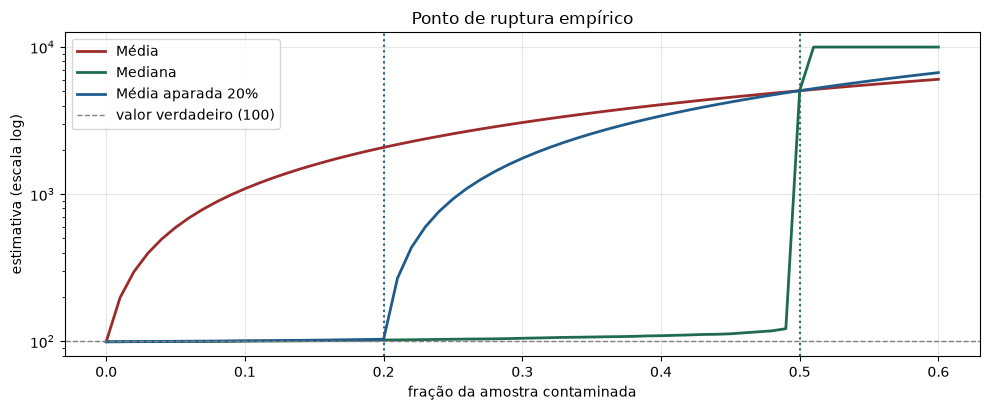

                      Média   Mediana  Média aparada 20%
fração contaminada                                      
0.00                  99.42     99.33              99.32
0.10                1089.44    100.26             100.83
0.19                1980.45    101.74             102.97
0.21                2178.53    102.27             268.44
0.49                4950.80    121.84            4887.94
0.51                5148.86  10000.00            5217.90


In [5]:
base = rng.normal(loc=100, scale=10, size=1000)
fracoes = np.linspace(0, 0.60, 61)

registro = []
for frac in fracoes:
    v = base.copy()
    k = int(frac * len(v))
    if k:
        v[:k] = 10_000.0                      # contaminação grosseira
    registro.append({
        "fração contaminada": frac,
        "Média": v.mean(),
        "Mediana": np.median(v),
        "Média aparada 20%": stats.trim_mean(v, 0.20),
    })

ruptura = pd.DataFrame(registro).set_index("fração contaminada")

fig, ax = plt.subplots(figsize=(10, 4.2))
for col, cor in zip(ruptura.columns, ["#9C2B2B", "#1E6B4F", "#1F5C8B"]):
    ax.plot(ruptura.index, ruptura[col], lw=2, label=col, color=cor)
ax.axhline(100, ls="--", color="gray", lw=1, label="valor verdadeiro (100)")
ax.axvline(0.20, ls=":", color="#1F5C8B", lw=1.5)
ax.axvline(0.50, ls=":", color="#1E6B4F", lw=1.5)
ax.set_yscale("log")
ax.set_xlabel("fração da amostra contaminada")
ax.set_ylabel("estimativa (escala log)")
ax.set_title("Ponto de ruptura empírico")
ax.legend()
plt.tight_layout()
plt.show()

print(ruptura.loc[[0.0, 0.10, 0.19, 0.21, 0.49, 0.51]].round(2).to_string())

As linhas pontilhadas marcam a teoria e os dados confirmam:

* A **média** sai do lugar imediatamente — ponto de ruptura 0%.
* A **média aparada 20%** segue exata até 20% e explode logo depois.
* A **mediana** segue exata até quase 50%.

## 3. O caso difícil: quando a cauda **não** é erro

Até aqui os extremos eram claramente defeito de sensor. Mas existe uma classe
enorme de fenômenos em que os extremos são reais, esperados e o ponto principal
da análise: **distribuições de cauda pesada** (lei de potência).

Exemplos: vendas por produto, receita por cliente, tamanho de cidade, danos de
catástrofe, downloads por pacote, seguidores por perfil.

A assinatura matemática: para uma Pareto com índice $\alpha \le 2$ a variância
é **infinita**; com $\alpha \le 1$ a própria **média** é infinita. Isso não é
uma curiosidade teórica — significa que a média amostral **nunca converge**.

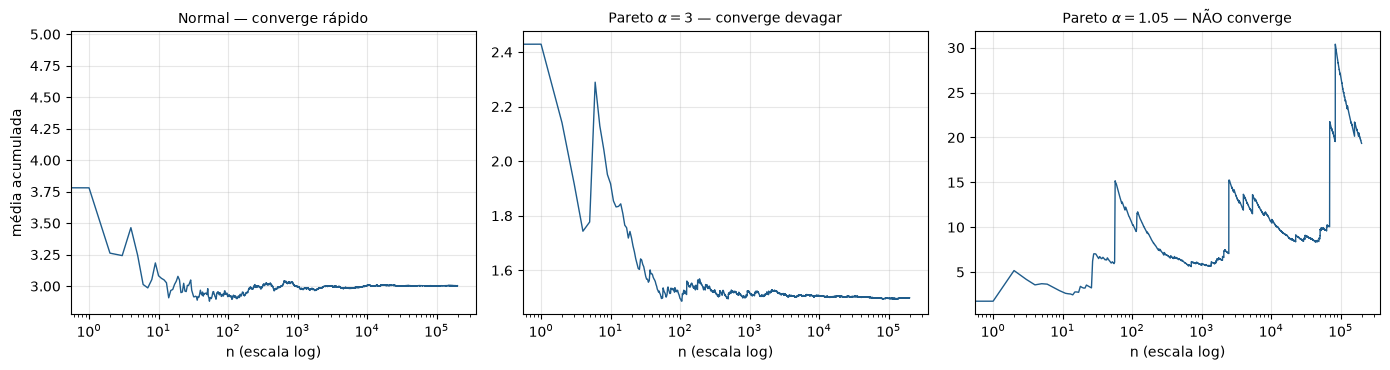

In [6]:
n = 200_000
pareto_leve = rng.pareto(a=3.0, size=n) + 1     # variância finita
pareto_pesada = rng.pareto(a=1.05, size=n) + 1  # média teoricamente infinita
normal = rng.normal(loc=3, scale=1, size=n)

def media_acumulada(v):
    return np.cumsum(v) / np.arange(1, len(v) + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharex=True)
for ax, (v, titulo) in zip(axes, [
        (normal, "Normal — converge rápido"),
        (pareto_leve, r"Pareto $\alpha=3$ — converge devagar"),
        (pareto_pesada, r"Pareto $\alpha=1.05$ — NÃO converge")]):
    ax.plot(media_acumulada(v), lw=1, color="#1F5C8B")
    ax.set_xscale("log")
    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel("n (escala log)")
axes[0].set_ylabel("média acumulada")
plt.tight_layout()
plt.show()

O terceiro painel é o retrato do problema. A média acumulada dá **saltos**
permanentes: cada novo recorde de valor extremo move a média e ela nunca
assenta. Com 200 mil observações a estimativa ainda é instável.

> **No mercado:** é exatamente por isso que "receita média por cliente" é uma
> métrica perigosa em negócios com cauda longa (SaaS enterprise, marketplaces,
> jogos com *whales*). Um único contrato fecha e o KPI do trimestre inteiro
> muda — sem que nada de estrutural tenha acontecido. Reporte **mediana e
> percentis**, e trate a cauda como um segmento separado com seu próprio
> modelo.

## 4. Um fluxograma de decisão para valores extremos

Detectar é a parte fácil. A decisão é o trabalho de gente sênior:

In [7]:
DECISAO = pd.DataFrame([
    ("Impossível no domínio (idade = -5, data futura)",
     "ERRO DE DADOS", "Corrigir na origem; se impossível, tratar como ausente"),
    ("Fisicamente possível mas implausível (salário 1000x a mediana)",
     "INVESTIGAR", "Buscar o registro cru; conferir unidade e moeda"),
    ("Plausível e recorrente (cliente enterprise)",
     "FENÔMENO REAL", "Manter; considerar segmento próprio ou feature indicadora"),
    ("Plausível, raro, e é o alvo (fraude, falha, churn de alto valor)",
     "É O OBJETIVO", "NUNCA remover — remover é apagar o rótulo positivo"),
    ("Cauda pesada intrínseca ao fenômeno",
     "MUDAR A FERRAMENTA", "Log-transformar, usar métrica robusta ou modelo de cauda"),
], columns=["Situação", "Classificação", "Ação recomendada"])

for _, linha in DECISAO.iterrows():
    print(f"▸ {linha['Situação']}")
    print(f"    → {linha['Classificação']}: {linha['Ação recomendada']}\n")

▸ Impossível no domínio (idade = -5, data futura)
    → ERRO DE DADOS: Corrigir na origem; se impossível, tratar como ausente

▸ Fisicamente possível mas implausível (salário 1000x a mediana)
    → INVESTIGAR: Buscar o registro cru; conferir unidade e moeda

▸ Plausível e recorrente (cliente enterprise)
    → FENÔMENO REAL: Manter; considerar segmento próprio ou feature indicadora

▸ Plausível, raro, e é o alvo (fraude, falha, churn de alto valor)
    → É O OBJETIVO: NUNCA remover — remover é apagar o rótulo positivo

▸ Cauda pesada intrínseca ao fenômeno
    → MUDAR A FERRAMENTA: Log-transformar, usar métrica robusta ou modelo de cauda



> **Armadilha profissional que vale um emprego:** em um projeto de detecção de
> fraude, aplicar "remover tudo que estiver fora de 3 desvios-padrão" como
> etapa de limpeza remove justamente as transações fraudulentas. O modelo
> treina num mundo sem fraude, atinge 99,9% de acurácia e não detecta nada.
> Limpeza de outliers **nunca** deve ser um passo automático aplicado antes de
> se entender o alvo.

## 5. Winsorização: a alternativa a remover

In [8]:
receita = rng.lognormal(mean=np.log(500), sigma=1.4, size=5_000)

# Winsorizar = SUBSTITUIR os extremos pelo valor do percentil-limite,
# em vez de EXCLUIR as linhas. Preserva o n e o fato de "este é um cliente
# grande", mas limita a influência.
p01, p99 = np.percentile(receita, [1, 99])
winsorizada = np.clip(receita, p01, p99)

comparacao = pd.DataFrame({
    "original": [receita.mean(), np.median(receita), receita.std(ddof=1),
                 stats.skew(receita), len(receita)],
    "winsorizada 1%/99%": [winsorizada.mean(), np.median(winsorizada),
                           winsorizada.std(ddof=1), stats.skew(winsorizada),
                           len(winsorizada)],
    "com remoção 1%/99%": [
        receita[(receita >= p01) & (receita <= p99)].mean(),
        np.median(receita[(receita >= p01) & (receita <= p99)]),
        receita[(receita >= p01) & (receita <= p99)].std(ddof=1),
        stats.skew(receita[(receita >= p01) & (receita <= p99)]),
        ((receita >= p01) & (receita <= p99)).sum()],
}, index=["média", "mediana", "desvio-padrão", "assimetria", "n"])
comparacao.round(3)

,original,winsorizada 1%/99%,com remoção 1%/99%
média,1293.037,1213.719,1114.776
mediana,496.734,496.734,496.734
desvio-padrão,2908.192,1966.654,1646.760
assimetria,15.937,3.423,3.182
n,5000.000,5000.000,4900.000


Note a última linha: a **winsorização preserva o `n`**, a remoção não. Isso
importa quando você precisa juntar a tabela de volta com outras (uma linha
removida vira `NaN` no join, e `NaN` se propaga silenciosamente).

## 6. Exercícios

1. Implemente a detecção por IQR com `k = 3.0` (o critério de "outlier
   extremo"). Refaça a tabela da seção 1. Quantos falsos positivos a mais o
   `k = 1.5` produz em dados **puramente normais** de 10.000 pontos? (Dica: a
   resposta teórica é ~0,7%. Esse é o preço fixo do boxplot.)
2. Gere dados **bimodais** (`np.concatenate` de duas normais bem separadas).
   O que a regra do IQR faz com eles? Por que nenhum ponto é marcado embora a
   distribuição seja claramente anômala? O que isso ensina sobre detectores
   univariados?
3. Um outlier **multivariado** pode ter todos os valores individuais normais.
   Simule altura e peso correlacionados e insira uma pessoa de 1,50 m e 120 kg
   — nenhum valor é extremo isoladamente. Implemente a **distância de
   Mahalanobis** e mostre que ela detecta.
4. Repita a seção 3 com `a=2.5`. A média converge? E a variância? Compare o
   desvio-padrão acumulado com a média acumulada.

## Próximo passo

`03-visualizacao-distribuicoes.ipynb` — o quarteto de Anscombe e por que
nenhuma tabela de estatísticas substitui um gráfico.